# Notebook 6 v4 — DIAGNOSTIC: Encoder Freeze + Head-Only Fine-tune

**Amaç:** v1/v2/v3 hepsi mal_AUC 0.66-0.69 plateau'sunda takıldı. Bu **diagnostic** notebook gerçek darboğazın ne olduğunu ortaya çıkarır:

- mal_AUC > 0.75 olursa → v1-v3'te **overfitting** sorunuyduk, çözüm var
- mal_AUC ~0.65 kalırsa → **encoder fundamentally yetersiz**, DAPT pretrain yeterli feature öğrenmemiş

## v4 farklar

| Konu | v3 | **v4** |
|---|---|---|
| Encoder | Trainable (300M param) | **FROZEN (DAPT ckpt sabit)** |
| Trainable parameters | ~325M | **~5M (sadece head'ler)** |
| Optimizer params | encoder + head | **head only** |
| Epoch sayısı | 25 | **10 (hızlı diagnostic)** |
| Train metrics log | yok | **var (overfitting tespiti)** |
| Soft CBM | ✓ | ✓ (korunur) |
| Prefix | cbm_ft_v3 | **cbm_ft_v4** |

## Diagnostic mantığı

300M parametre × 870 pozitif sample = aşırı parametrize. Encoder fine-tune'da kolayca overfit eder.

Encoder frozen → sadece 5M trainable param. Aşırı parametrize değil, overfitting riski minimum.

DAPT encoder zaten CT anatomy biliyor. Bilgisi sabit kalır, head'ler buna göre öğrenir.

**Senaryo A — mal_AUC 0.75+**: sorun fine-tune sırasında encoder'ın overfit etmesiydi. Çözüm: encoder freeze veya çok daha agresif regularization.

**Senaryo B — mal_AUC 0.65**: encoder'da öğrenilmiş feature'ların yetersizliği. Çözüm: yeni pretrain, farklı backbone, veya mevcut sonuçlarla tezde "limitation" olarak yaz.

## Pipeline

1. Setup + paths + Drive→local H5 copy
2. Telegram + Drive resilience helpers
3. `LUNA16PatchDataset` (H5 reader + augmentation)
4. DataLoader setup
5. Model + decoder + heads (Notebook 5'in mimarisi, self-contained)
6. DAPT encoder yükle
7. Loss function
8. Optimizer + scheduler (encoder/head ayrı LR)
9. Validation + metrics (AUC, Dice, R²)
10. Checkpoint manager (best + last)
11. Train one epoch
12. Resume support
13. Main training loop
14. Test set evaluation
15. Özet


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, json, gc, shutil, signal
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import roc_auc_score, r2_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import requests

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


## 2. MONAI yükle

In [2]:
!pip install monai --quiet
from monai.networks.nets import ViT
print('MONAI yüklendi')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 62.8 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI yüklendi


## 3. Yollar ve config

In [3]:
# === GİRDİLER ===
DAPT_CKPT = '/content/drive/MyDrive/bitirme/Checkpoints_DAPT/pulmomae_dapt_epoch3_20260525-210449_model_only.pth'
DRIVE_PATCHES_DIR = '/content/drive/MyDrive/bitirme/Finetune_Patches'
LOCAL_PATCHES_DIR = '/content/patches_local'

# === ÇIKTILAR ===
CHECKPOINTS_DIR = '/content/drive/MyDrive/bitirme/Checkpoints_Finetune'
LOCAL_CKPT_STAGING = '/content/_ft_ckpt_staging'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(LOCAL_CKPT_STAGING, exist_ok=True)

# === MODEL CONFIG === (Notebook 5 ile aynı)
ROI_SIZE = (64, 64, 64)
PATCH_SIZE = (16, 16, 16)
HIDDEN_SIZE = 1024
MLP_DIM = 4096
NUM_LAYERS = 24
NUM_HEADS = 16
N_CONCEPTS = 8
SKIP_LAYERS = (6, 12, 18)

# === TRAINING CONFIG ===
NUM_EPOCHS = 10          # v4 diagnostic: hızlı feedback
BATCH_SIZE = 64          # A100 80GB → ~63 GB peak, marj OK
GRAD_ACCUM_STEPS = 1     # effective batch = 64
NUM_WORKERS = 8
ENCODER_LR = 5e-6        # v4: encoder freeze, bu kullanılmaz ama bırak
HEAD_LR = 1.5e-4
WEIGHT_DECAY = 1e-4

# v2 fix: detection class imbalance için pozitif sınıfa ağırlık
DET_POS_WEIGHT = 4.0     # negatives:positives ~5:1, weighted CE bunu dengeler

# v2 fix: concept'leri normalize et 1-5 → 0-1 (MSE küçülür, gradient'i daha temiz)
CONCEPT_NORMALIZE = True

# === v4 DIAGNOSTIC FLAGS ===
FREEZE_ENCODER = True    # Encoder DAPT ckpt'tan yüklenir, train edilmez
LOG_TRAIN_METRICS = True # Train AUC'ları da hesapla (overfitting tespiti)

# v4 prefix: eski v1/v2/v3 ckpt'leri ile karışmasın
CKPT_PREFIX = 'cbm_ft_v4'
WARMUP_FRACTION = 0.1   # ilk %10 warmup
MAX_GRAD_NORM = 1.0

# Loss weights — v2: concept normalize edildi (0-1), MSE artık küçük
# v1: concept_loss ~14 (target 1-5) → weight 0.1 lazımdı
# v2: concept_loss ~0.25 (target 0-1) → weight 1.0 OK, dengeli sinyal
LOSS_WEIGHTS = {
    'detection':    1.0,
    'segmentation': 1.0,
    'malignancy':   1.0,
    'concepts':     1.0,   # v1: 0.1 → v2: 1.0 (normalize sonrası MSE düşük)
}

# Augmentation
AUGMENT_TRAIN = True

# Telegram
TELEGRAM_TOKEN  = '8778723398:AAGS-2c5ddGegnc1ErMf1Lz2RZ_xVSwq3c8'
TELEGRAM_CHATID = '7689600055'

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Konfigürasyon OK')
print(f'  Epochs: {NUM_EPOCHS}, batch {BATCH_SIZE} × accum {GRAD_ACCUM_STEPS} = effective {BATCH_SIZE*GRAD_ACCUM_STEPS}')
print(f'  Encoder LR: {ENCODER_LR:.0e}, Head LR: {HEAD_LR:.0e}')
print(f'  Loss weights: {LOSS_WEIGHTS}')

Konfigürasyon OK
  Epochs: 10, batch 64 × accum 1 = effective 64
  Encoder LR: 5e-06, Head LR: 1e-04
  Loss weights: {'detection': 1.0, 'segmentation': 1.0, 'malignancy': 1.0, 'concepts': 1.0}


## 4. H5 dosyalarını Drive'dan /content/'e kopyala

Bu Drive I/O bottleneck'ini ortadan kaldırır. ~3 GB toplam, 3-5 dakika sürer.

In [4]:
os.makedirs(LOCAL_PATCHES_DIR, exist_ok=True)

local_train = os.path.join(LOCAL_PATCHES_DIR, 'patches_train.h5')
local_val   = os.path.join(LOCAL_PATCHES_DIR, 'patches_val.h5')
local_test  = os.path.join(LOCAL_PATCHES_DIR, 'patches_test.h5')

drive_train = os.path.join(DRIVE_PATCHES_DIR, 'patches_train.h5')
drive_val   = os.path.join(DRIVE_PATCHES_DIR, 'patches_val.h5')
drive_test  = os.path.join(DRIVE_PATCHES_DIR, 'patches_test.h5')

for src, dst, name in [(drive_train, local_train, 'train'),
                        (drive_val, local_val, 'val'),
                        (drive_test, local_test, 'test')]:
    if os.path.exists(dst) and os.path.getsize(dst) == os.path.getsize(src):
        print(f'{name}: zaten local\'de mevcut ({os.path.getsize(dst)/(1024*1024):.0f} MB)')
        continue
    t0 = time.time()
    print(f'Copying {name} ({os.path.getsize(src)/(1024*1024):.0f} MB)...')
    shutil.copy(src, dst)
    dt = time.time() - t0
    print(f'  Tamamlandı: {dt:.1f}s ({os.path.getsize(dst)/(1024*1024)/dt:.0f} MB/s)')

print('\nLocal H5 dosyaları hazır ✅')

Copying train (1966 MB)...
  Tamamlandı: 45.0s (44 MB/s)
Copying val (374 MB)...
  Tamamlandı: 8.4s (44 MB/s)
Copying test (379 MB)...
  Tamamlandı: 9.5s (40 MB/s)

Local H5 dosyaları hazır ✅


## 5. Telegram + Drive resilience helpers

In [5]:
def send_telegram(msg, image_path=None):
    try:
        requests.post(
            f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage',
            data={'chat_id': TELEGRAM_CHATID, 'text': msg, 'parse_mode': 'Markdown'},
            timeout=15,
        )
        if image_path and os.path.exists(image_path):
            with open(image_path, 'rb') as f:
                requests.post(
                    f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto',
                    data={'chat_id': TELEGRAM_CHATID},
                    files={'photo': f}, timeout=20,
                )
    except Exception as e:
        print(f'Telegram hata: {e}')

from google.colab import drive as gdrive
def ensure_drive():
    try:
        os.listdir('/content/drive/MyDrive')
        return True
    except OSError:
        print('  Drive remount...')
        try:
            gdrive.mount('/content/drive', force_remount=True)
            time.sleep(3)
            return True
        except Exception:
            return False

print('Helpers OK')

Helpers OK


## 6. H5 LUNA16PatchDataset

Lazy h5py.File açma (multi-worker pickle uyumlu), augmentation, label paketleme.

In [6]:
class LUNA16PatchDataset(Dataset):
    """
    H5'ten patch okur, multi-task labels döner.

    Returns dict:
      patch:         (1, 64, 64, 64) float32 [0, 1]
      mask:          (1, 64, 64, 64) float32 {0, 1}
      detection:     scalar long (0/1)
      malignancy:    scalar long (-1=ignore, 0=benign, 1=malign)
      seg_loss_mask: scalar float (1.0 mask varsa)
      concepts:      (8,) float32 (-1=ignore default)
    """

    def __init__(self, h5_path, training=False, augment=False, hu_clip=(-1000, 1000)):
        self.h5_path = h5_path
        self.training = training
        self.augment = augment and training
        self.hu_clip = hu_clip
        self._h5 = None  # lazy worker-local handle

        # Index'leri ve labels'i bir kere oku (küçük, RAM'e sığar)
        with h5py.File(h5_path, 'r') as h5:
            self.N = h5['patches'].shape[0]
            self.detection_all   = h5['detection'][:]
            self.malignancy_all  = h5['malignancy'][:]
            self.seg_loss_all    = h5['seg_loss_mask'][:]
            self.concepts_all    = h5['concepts'][:]

    def __len__(self):
        return self.N

    def _open_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def _augment(self, patch, mask):
        # Flip 3 eksen, her biri %50
        for axis in [0, 1, 2]:
            if np.random.rand() < 0.5:
                patch = np.flip(patch, axis=axis)
                mask = np.flip(mask, axis=axis)
        # Rot90 axial plane (YX)
        k = np.random.randint(0, 4)
        if k > 0:
            patch = np.rot90(patch, k=k, axes=(1, 2))
            mask = np.rot90(mask, k=k, axes=(1, 2))
        patch = np.ascontiguousarray(patch)
        mask = np.ascontiguousarray(mask)
        # Mild Gaussian noise %30
        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 0.02, patch.shape).astype(np.float32)
            patch = np.clip(patch + noise, 0.0, 1.0)
        return patch, mask

    def __getitem__(self, idx):
        h5 = self._open_h5()
        patch = h5['patches'][idx]  # int16 HU
        mask = h5['masks'][idx]      # uint8

        # HU clip + normalize → [0, 1] (pretrain ile birebir)
        patch = np.clip(patch.astype(np.float32), self.hu_clip[0], self.hu_clip[1])
        patch = (patch - self.hu_clip[0]) / (self.hu_clip[1] - self.hu_clip[0])

        mask = mask.astype(np.uint8)

        if self.augment:
            patch, mask = self._augment(patch, mask)

        # Channel dim
        patch_t = torch.from_numpy(patch[np.newaxis, ...])
        mask_t = torch.from_numpy(mask[np.newaxis, ...]).float()

        # === v2 fix: Concept normalize 1-5 → 0-1 ===
        # -1.0 (no match) değerleri korunur, geçerli concept'ler [0, 1]'e çekilir
        concepts = self.concepts_all[idx].astype(np.float32).copy()
        if CONCEPT_NORMALIZE and concepts[0] != -1.0:
            # Tüm 8 concept 1-5 (calcification 1-6) aralığında, /4.0 ile normalize
            # Calcification için 1-6 → 0-1.25 olur, biraz dışına çıkar ama loss'a etkisi az
            concepts = (concepts - 1.0) / 4.0
            concepts = np.clip(concepts, 0.0, 1.5)

        return {
            'patch':         patch_t,
            'mask':          mask_t,
            'detection':     torch.tensor(self.detection_all[idx], dtype=torch.long),
            'malignancy':    torch.tensor(self.malignancy_all[idx], dtype=torch.long),
            'seg_loss_mask': torch.tensor(self.seg_loss_all[idx], dtype=torch.float),
            'concepts':      torch.from_numpy(concepts),
        }

print('LUNA16PatchDataset tanımlandı ✅')

LUNA16PatchDataset tanımlandı ✅


## 7. DataLoader'lar

In [7]:
train_ds = LUNA16PatchDataset(local_train, training=True,  augment=AUGMENT_TRAIN)
val_ds   = LUNA16PatchDataset(local_val,   training=False, augment=False)
test_ds  = LUNA16PatchDataset(local_test,  training=False, augment=False)

print(f'Train: {len(train_ds)} sample')
print(f'  pos: {(train_ds.detection_all == 1).sum()}, neg: {(train_ds.detection_all == 0).sum()}')
print(f'  malignancy valid: {(train_ds.malignancy_all != -1).sum()}')
print(f'  seg_loss_mask=1: {(train_ds.seg_loss_all == 1).sum()}')
print(f'  concepts valid: {(train_ds.concepts_all[:, 0] != -1.0).sum()}')

print(f'\nVal:   {len(val_ds)} sample')
print(f'Test:  {len(test_ds)} sample')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True,
                           persistent_workers=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True,
                           persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nBatch sayıları:')
print(f'  Train: {len(train_loader)}')
print(f'  Val:   {len(val_loader)}')
print(f'  Test:  {len(test_loader)}')

# Smoke test
batch = next(iter(train_loader))
print(f'\nİlk batch shapes:')
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f'  {k:15s}: {tuple(v.shape)} {v.dtype}')

Train: 5870 sample
  pos: 870, neg: 5000
  malignancy valid: 574
  seg_loss_mask=1: 864
  concepts valid: 859

Val:   1100 sample
Test:  1130 sample

Batch sayıları:
  Train: 91
  Val:   18
  Test:  18

İlk batch shapes:
  patch          : (64, 1, 64, 64, 64) torch.float32
  mask           : (64, 1, 64, 64, 64) torch.float32
  detection      : (64,) torch.int64
  malignancy     : (64,) torch.int64
  seg_loss_mask  : (64,) torch.float32
  concepts       : (64, 8) torch.float32


## 8. Model class'ları (Notebook 5'ten copy)

Notebook self-contained olsun diye yeniden tanımlanıyor.

In [8]:
class UNETRLiteDecoder(nn.Module):
    def __init__(self, encoder_dim=1024, n_per_dim=4, skip_layers=(6, 12, 18)):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.n_per_dim = n_per_dim
        self.skip_layers = skip_layers

        self.skip1 = self._skip_block(encoder_dim, 256, scale=2)
        self.skip2 = self._skip_block(encoder_dim, 128, scale=4)
        self.skip3 = self._skip_block(encoder_dim,  64, scale=8)

        self.up1 = nn.ConvTranspose3d(encoder_dim, 512, 2, 2)
        self.merge1 = self._merge_block(512 + 256, 512)
        self.up2 = nn.ConvTranspose3d(512, 256, 2, 2)
        self.merge2 = self._merge_block(256 + 128, 256)
        self.up3 = nn.ConvTranspose3d(256, 128, 2, 2)
        self.merge3 = self._merge_block(128 + 64, 128)
        self.up4 = nn.ConvTranspose3d(128, 64, 2, 2)
        self.final = nn.Sequential(
            nn.Conv3d(64, 64, 3, padding=1),
            nn.InstanceNorm3d(64), nn.GELU(),
            nn.Conv3d(64, 1, 1),
        )

    def _skip_block(self, in_ch, out_ch, scale):
        return nn.Sequential(
            nn.ConvTranspose3d(in_ch, out_ch, scale, scale),
            nn.InstanceNorm3d(out_ch), nn.GELU(),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch), nn.GELU(),
        )

    def _merge_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch), nn.GELU(),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch), nn.GELU(),
        )

    def _tokens_to_3d(self, tokens):
        B = tokens.shape[0]
        x = tokens.view(B, self.n_per_dim, self.n_per_dim, self.n_per_dim, self.encoder_dim)
        return x.permute(0, 4, 1, 2, 3).contiguous()

    def forward(self, tokens, hidden_states):
        skip1 = self._tokens_to_3d(hidden_states[self.skip_layers[2] - 1])
        skip2 = self._tokens_to_3d(hidden_states[self.skip_layers[1] - 1])
        skip3 = self._tokens_to_3d(hidden_states[self.skip_layers[0] - 1])

        skip1_8  = self.skip1(skip1)
        skip2_16 = self.skip2(skip2)
        skip3_32 = self.skip3(skip3)

        x = self._tokens_to_3d(tokens)
        x = self.up1(x);  x = torch.cat([x, skip1_8], dim=1);  x = self.merge1(x)
        x = self.up2(x);  x = torch.cat([x, skip2_16], dim=1); x = self.merge2(x)
        x = self.up3(x);  x = torch.cat([x, skip3_32], dim=1); x = self.merge3(x)
        x = self.up4(x);  x = self.final(x)
        return x


class CBMMultiTaskModel(nn.Module):
    def __init__(self, roi_size=(64,64,64), patch_size=(16,16,16),
                 hidden_size=1024, mlp_dim=4096, num_layers=24, num_heads=16,
                 n_concepts=8, skip_layers=(6,12,18), head_hidden=256, head_dropout=0.1):
        super().__init__()
        self.n_concepts = n_concepts

        self.encoder = ViT(
            in_channels=1, img_size=roi_size, patch_size=patch_size,
            hidden_size=hidden_size, mlp_dim=mlp_dim,
            num_layers=num_layers, num_heads=num_heads, classification=False,
        )
        self.detection_head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, head_hidden), nn.GELU(), nn.Dropout(head_dropout),
            nn.Linear(head_hidden, 2),
        )
        self.concept_head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, head_hidden), nn.GELU(), nn.Dropout(head_dropout),
            nn.Linear(head_hidden, n_concepts),
        )
        # === v3: Soft CBM ===
        # v1/v2: Linear(8 -> 2) — hard bottleneck, sadece concept'ten besleniyordu
        # v3: MLP(8+1024 -> 128 -> 2) — concept VE encoder feature'larından
        self.malignancy_head = nn.Sequential(
            nn.LayerNorm(n_concepts + hidden_size),
            nn.Linear(n_concepts + hidden_size, 128), nn.GELU(), nn.Dropout(head_dropout),
            nn.Linear(128, 2),
        )
        self.seg_decoder = UNETRLiteDecoder(
            encoder_dim=hidden_size,
            n_per_dim=roi_size[0] // patch_size[0],
            skip_layers=skip_layers,
        )

    def forward(self, x):
        tokens, hidden_states = self.encoder(x)
        global_feat = tokens.mean(dim=1)
        det = self.detection_head(global_feat)
        concepts = self.concept_head(global_feat)
        # v3: Soft CBM — malignancy hem concept hem encoder feature'dan
        mal_input = torch.cat([concepts, global_feat], dim=1)
        mal = self.malignancy_head(mal_input)
        seg = self.seg_decoder(tokens, hidden_states)
        return {'detection': det, 'concepts': concepts, 'malignancy': mal, 'segmentation': seg}

print('Model class\'ları tanımlandı ✅')

Model class'ları tanımlandı ✅


## 9. Model oluştur, DAPT encoder yükle

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CBMMultiTaskModel(
    roi_size=ROI_SIZE, patch_size=PATCH_SIZE,
    hidden_size=HIDDEN_SIZE, mlp_dim=MLP_DIM,
    num_layers=NUM_LAYERS, num_heads=NUM_HEADS,
    n_concepts=N_CONCEPTS, skip_layers=SKIP_LAYERS,
).to(device)

print(f'Model: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parametre')

# DAPT encoder yükle
print(f'\nDAPT ckpt: {os.path.basename(DAPT_CKPT)}')
ckpt = torch.load(DAPT_CKPT, map_location=device)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    encoder_state = ckpt['model_state_dict']
else:
    encoder_state = ckpt
missing, unexpected = model.encoder.load_state_dict(encoder_state, strict=False)
print(f'  Eksik: {len(missing)}, Beklenmedik: {len(unexpected)}')
print(f'  ✅ Encoder yüklendi')

# === v4 DIAGNOSTIC: Encoder freeze ===
if FREEZE_ENCODER:
    for p in model.encoder.parameters():
        p.requires_grad = False
    model.encoder.eval()  # BatchNorm/Dropout sabit

    n_total = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_frozen = n_total - n_trainable
    print(f'\n🧊 ENCODER FROZEN (v4 diagnostic)')
    print(f'   Toplam:    {n_total/1e6:.1f}M')
    print(f'   Trainable: {n_trainable/1e6:.1f}M (head\'ler)')
    print(f'   Frozen:    {n_frozen/1e6:.1f}M (encoder)')

Model: 483.2M parametre

DAPT ckpt: pulmomae_dapt_epoch3_20260525-210449_model_only.pth
  Eksik: 0, Beklenmedik: 0
  ✅ Encoder yüklendi

🧊 ENCODER FROZEN (v4 diagnostic)
   Toplam:    483.2M
   Trainable: 75.9M (head'ler)
   Frozen:    407.2M (encoder)


## 10. Multi-task loss

In [10]:
def multitask_loss(outputs, batch, weights, eps=1e-7):
    losses = {}

    # v2 fix: Detection weighted CE (pos class 4× ağırlık)
    det_logits = outputs['detection']
    det_target = batch['detection']
    det_class_weight = torch.tensor([1.0, DET_POS_WEIGHT], device=det_logits.device)
    losses['detection'] = F.cross_entropy(det_logits, det_target, weight=det_class_weight)

    # Malignancy (ignore -1)
    mal_logits = outputs['malignancy']
    mal_target = batch['malignancy']
    if (mal_target != -1).any():
        losses['malignancy'] = F.cross_entropy(mal_logits, mal_target, ignore_index=-1)
    else:
        losses['malignancy'] = torch.tensor(0.0, device=mal_logits.device)

    # Segmentation (Dice + BCE, mask'li)
    seg_logits = outputs['segmentation']
    seg_target = batch['mask'].float()
    seg_mask = batch['seg_loss_mask'].view(-1, 1, 1, 1, 1).float()

    bce_per_voxel = F.binary_cross_entropy_with_logits(seg_logits, seg_target, reduction='none')
    bce = (bce_per_voxel * seg_mask).sum() / (seg_mask.sum() * 64*64*64 + eps)

    seg_probs = torch.sigmoid(seg_logits)
    dims = (2, 3, 4)
    inter = (seg_probs * seg_target).sum(dim=dims).sum(dim=1)
    union = seg_probs.sum(dim=dims).sum(dim=1) + seg_target.sum(dim=dims).sum(dim=1)
    dice_per_sample = 1.0 - (2.0 * inter + 1.0) / (union + 1.0)
    smps = seg_mask.view(-1)
    if smps.sum() > 0:
        dice_loss = (dice_per_sample * smps).sum() / (smps.sum() + eps)
    else:
        dice_loss = torch.tensor(0.0, device=seg_logits.device)
    losses['segmentation'] = bce + dice_loss

    # Concepts (MSE, mask'li) — v2'de target [0, 1] aralığında, MSE doğal düşük
    cp = outputs['concepts']
    ct = batch['concepts'].float()
    cm = (ct[:, 0] != -1.0).float().unsqueeze(1)
    mse_per = F.mse_loss(cp, ct, reduction='none')
    if cm.sum() > 0:
        losses['concepts'] = (mse_per * cm).sum() / (cm.sum() * cp.shape[1] + eps)
    else:
        losses['concepts'] = torch.tensor(0.0, device=cp.device)

    # Weighted total
    losses['total'] = (weights['detection']    * losses['detection']
                     + weights['segmentation'] * losses['segmentation']
                     + weights['malignancy']   * losses['malignancy']
                     + weights['concepts']     * losses['concepts'])
    return losses

print('multitask_loss OK ✅')

multitask_loss OK ✅


## 11. Optimizer + Scheduler (encoder/head ayrı LR)

In [11]:
# v4: Encoder frozen, sadece head'leri optimize et
head_params = (list(model.detection_head.parameters()) +
               list(model.concept_head.parameters()) +
               list(model.malignancy_head.parameters()) +
               list(model.seg_decoder.parameters()))

if FREEZE_ENCODER:
    # Sadece head'ler
    optimizer = torch.optim.AdamW([
        {'params': head_params, 'lr': HEAD_LR, 'name': 'head'},
    ], weight_decay=WEIGHT_DECAY)
    n_param_groups = 1
    print(f'Optimizer: head-only, {sum(p.numel() for p in head_params)/1e6:.1f}M params')
else:
    encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': encoder_params, 'lr': ENCODER_LR, 'name': 'encoder'},
        {'params': head_params,    'lr': HEAD_LR,    'name': 'head'},
    ], weight_decay=WEIGHT_DECAY)
    n_param_groups = 2

# Cosine with warmup
total_steps = NUM_EPOCHS * (len(train_loader) // GRAD_ACCUM_STEPS)
warmup_steps = max(1, int(total_steps * WARMUP_FRACTION))
print(f'Total optimizer steps: {total_steps}, warmup: {warmup_steps}')

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

# Scheduler: param group sayısı kadar lr_lambda
scheduler = LambdaLR(optimizer, lr_lambda=[lr_lambda] * n_param_groups)

scaler = GradScaler('cuda')
print('Optimizer + scheduler + scaler OK ✅')

Optimizer: head-only, 75.9M params
Total optimizer steps: 910, warmup: 91
Optimizer + scheduler + scaler OK ✅


## 12. Metric helpers — AUC, Dice, R²

In [12]:
def compute_metrics(model, loader, device, max_batches=None):
    """Validation/test set'i ile geç, metrikleri topla."""
    model.eval()
    all_det_logits, all_det_target = [], []
    all_mal_logits, all_mal_target = [], []
    seg_dices = []
    all_concept_pred, all_concept_target = [], []

    losses_acc = {'detection': 0, 'malignancy': 0, 'segmentation': 0, 'concepts': 0, 'total': 0}
    n_batches = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='  Eval', leave=False)
        for batch_idx, batch in enumerate(pbar):
            if max_batches and batch_idx >= max_batches:
                break
            batch = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

            with autocast('cuda', dtype=torch.bfloat16):
                out = model(batch['patch'])
                losses = multitask_loss(out, batch, LOSS_WEIGHTS)

            for k in losses_acc:
                losses_acc[k] += losses[k].item()
            n_batches += 1

            # Detection
            all_det_logits.append(out['detection'].float().cpu().numpy())
            all_det_target.append(batch['detection'].cpu().numpy())

            # Malignancy (sadece valid)
            mal_valid = batch['malignancy'] != -1
            if mal_valid.any():
                all_mal_logits.append(out['malignancy'][mal_valid].float().cpu().numpy())
                all_mal_target.append(batch['malignancy'][mal_valid].cpu().numpy())

            # Segmentation (sadece seg_loss_mask=1 olanlar)
            seg_probs = torch.sigmoid(out['segmentation']).float()
            seg_target = batch['mask']
            seg_mask = batch['seg_loss_mask']
            for i in range(seg_target.shape[0]):
                if seg_mask[i].item() > 0:
                    p = (seg_probs[i] > 0.5).float()
                    t = seg_target[i].float()
                    inter = (p * t).sum().item()
                    union = p.sum().item() + t.sum().item()
                    dice = (2 * inter + 1) / (union + 1)
                    seg_dices.append(dice)

            # Concepts (sadece valid)
            cp = out['concepts'].float().cpu().numpy()
            ct = batch['concepts'].cpu().numpy()
            valid_concept = ct[:, 0] != -1.0
            if valid_concept.any():
                all_concept_pred.append(cp[valid_concept])
                all_concept_target.append(ct[valid_concept])

    metrics = {'losses': {k: v/n_batches for k, v in losses_acc.items()}}

    # AUC
    if all_det_logits:
        det_logits = np.concatenate(all_det_logits, axis=0)
        det_target = np.concatenate(all_det_target, axis=0)
        det_probs = torch.softmax(torch.from_numpy(det_logits), dim=1)[:, 1].numpy()
        try: metrics['det_auc'] = roc_auc_score(det_target, det_probs)
        except: metrics['det_auc'] = float('nan')

    if all_mal_logits:
        mal_logits = np.concatenate(all_mal_logits, axis=0)
        mal_target = np.concatenate(all_mal_target, axis=0)
        mal_probs = torch.softmax(torch.from_numpy(mal_logits), dim=1)[:, 1].numpy()
        try: metrics['mal_auc'] = roc_auc_score(mal_target, mal_probs)
        except: metrics['mal_auc'] = float('nan')
    else:
        metrics['mal_auc'] = float('nan')

    # Dice
    metrics['seg_dice'] = float(np.mean(seg_dices)) if seg_dices else float('nan')

    # Concept R²
    if all_concept_pred:
        cp = np.concatenate(all_concept_pred, axis=0)
        ct = np.concatenate(all_concept_target, axis=0)
        try: metrics['concept_r2'] = r2_score(ct, cp, multioutput='uniform_average')
        except: metrics['concept_r2'] = float('nan')
    else:
        metrics['concept_r2'] = float('nan')

    return metrics

print('compute_metrics OK ✅')

compute_metrics OK ✅


## 13. Checkpoint manager (best + last 2)

In [13]:
def save_checkpoint(epoch, model, optimizer, scheduler, scaler, metrics, tag, prefix=None):
    """Drive'a model_only ve full_state olarak kaydet."""
    if prefix is None:
        prefix = CKPT_PREFIX
    timestamp = time.strftime('%Y%m%d-%H%M%S')

    # Önce local'e yaz (Drive instabil)
    fname_full = f'{prefix}_epoch{epoch}_{tag}_{timestamp}_full.pth'
    fname_only = f'{prefix}_epoch{epoch}_{tag}_{timestamp}_model.pth'
    local_full = os.path.join(LOCAL_CKPT_STAGING, fname_full)
    local_only = os.path.join(LOCAL_CKPT_STAGING, fname_only)

    state = {
        'epoch': epoch,
        'tag': tag,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
        'config': {
            'roi_size': ROI_SIZE, 'patch_size': PATCH_SIZE,
            'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
            'n_concepts': N_CONCEPTS, 'skip_layers': SKIP_LAYERS,
        },
    }

    torch.save(state, local_full)
    torch.save(state['model_state_dict'], local_only)

    # Drive'a kopyala
    for local, name in [(local_full, fname_full), (local_only, fname_only)]:
        try:
            shutil.copy(local, os.path.join(CHECKPOINTS_DIR, name))
            os.remove(local)
        except Exception as e:
            print(f'  ⚠️ {name} Drive\'a yazılamadı: {e}')

    return fname_full


def cleanup_old_checkpoints(prefix=None, keep_last=2):
    """Best dışında son keep_last checkpoint dışındakileri sil."""
    if prefix is None:
        prefix = CKPT_PREFIX
    files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                     if f.startswith(prefix) and 'best' not in f and f.endswith('_full.pth')])
    if len(files) > keep_last:
        for old in files[:-keep_last]:
            # Hem _full hem _model versiyonunu sil
            for suffix in ['_full.pth', '_model.pth']:
                base = old.replace('_full.pth', suffix)
                path = os.path.join(CHECKPOINTS_DIR, base)
                if os.path.exists(path):
                    try: os.remove(path); print(f'  Eski sil: {base}')
                    except: pass

print('Checkpoint manager OK ✅')

Checkpoint manager OK ✅


## 14. Train one epoch

In [14]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, weights, device, epoch, accum_steps):
    model.train()
    losses_acc = {'detection': 0, 'malignancy': 0, 'segmentation': 0, 'concepts': 0, 'total': 0}
    n_batches = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f'  Epoch {epoch} train', leave=False)
    for batch_idx, batch in enumerate(pbar):
        batch = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        with autocast('cuda', dtype=torch.bfloat16):
            out = model(batch['patch'])
            losses = multitask_loss(out, batch, weights)
            loss_norm = losses['total'] / accum_steps

        scaler.scale(loss_norm).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        for k in losses_acc:
            losses_acc[k] += losses[k].item()
        n_batches += 1

        if batch_idx % 10 == 0:
            cur_lr = optimizer.param_groups[-1]['lr']  # head her zaman son group
            pbar.set_postfix(
                loss=f'{losses["total"].item():.3f}',
                lr=f'{cur_lr:.1e}',
            )

    # Son grad accum
    if n_batches % accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()

    return {k: v/n_batches for k, v in losses_acc.items()}

print('train_one_epoch OK ✅')

train_one_epoch OK ✅


## 15. Resume support

In [15]:
def find_latest_checkpoint(prefix=None):
    """En yeni full_state checkpoint'i bul. v2 prefix only."""
    if prefix is None:
        prefix = CKPT_PREFIX
    files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                     if f.startswith(prefix) and f.endswith('_full.pth')])
    if not files: return None
    return os.path.join(CHECKPOINTS_DIR, files[-1])


def maybe_resume(model, optimizer, scheduler, scaler):
    latest = find_latest_checkpoint()
    if latest is None:
        print('ℹ️ v2 resume yok — fresh start')
        return 0, float('-inf'), None

    print(f'📥 Resume: {os.path.basename(latest)}')
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])

    start_epoch = ckpt['epoch'] + 1
    best_metric = ckpt.get('best_val_mal_auc', float('-inf'))
    print(f'   Devam: epoch {start_epoch}, best mal_auc: {best_metric:.4f}')
    return start_epoch, best_metric, ckpt.get('metrics')

print('Resume support OK ✅')

Resume support OK ✅


## 16. Ana training loop

Bu hücre uzun süre çalışır. Telegram'dan her epoch sonu bildirim alacaksın.

In [16]:
# Resume kontrol
start_epoch, best_mal_auc, last_metrics = maybe_resume(model, optimizer, scheduler, scaler)

send_telegram(
    f'🚀 *Multi-task fine-tune başladı*\n\n'
    f'Epoch: {start_epoch} → {NUM_EPOCHS}\n'
    f'Batch: {BATCH_SIZE} × accum {GRAD_ACCUM_STEPS}\n'
    f'LR: enc {ENCODER_LR:.0e}, head {HEAD_LR:.0e}\n'
    f'Loss weights: {LOSS_WEIGHTS}'
)

history = []

try:
    for epoch in range(start_epoch, NUM_EPOCHS):
        epoch_start = time.time()

        # Train
        train_losses = train_one_epoch(model, train_loader, optimizer, scheduler, scaler,
                                         LOSS_WEIGHTS, device, epoch, GRAD_ACCUM_STEPS)

        # Validation
        val_metrics = compute_metrics(model, val_loader, device)

        # v4: Train metrikleri (overfitting tespiti)
        train_metrics = None
        if LOG_TRAIN_METRICS:
            # Train metric'i hesapla ama hızlı olsun: max 30 batch (~1920 sample)
            train_metrics = compute_metrics(model, train_loader, device, max_batches=30)

        epoch_dt = time.time() - epoch_start

        log_line = (f'\n━━━ EPOCH {epoch+1}/{NUM_EPOCHS} | {epoch_dt/60:.1f} dk ━━━\n'
                    f'Train loss: total={train_losses["total"]:.3f}, '
                    f'det={train_losses["detection"]:.3f}, '
                    f'seg={train_losses["segmentation"]:.3f}, '
                    f'mal={train_losses["malignancy"]:.3f}, '
                    f'con={train_losses["concepts"]:.3f}\n')
        if train_metrics:
            log_line += (f'Train metrics: '
                         f'det_AUC={train_metrics["det_auc"]:.4f}, '
                         f'mal_AUC={train_metrics["mal_auc"]:.4f}, '
                         f'Dice={train_metrics["seg_dice"]:.4f}, '
                         f'concept_R²={train_metrics["concept_r2"]:.4f}\n')
        log_line += (f'Val metrics:   '
                    f'det_AUC={val_metrics["det_auc"]:.4f}, '
                    f'mal_AUC={val_metrics["mal_auc"]:.4f}, '
                    f'Dice={val_metrics["seg_dice"]:.4f}, '
                    f'concept_R²={val_metrics["concept_r2"]:.4f}\n')
        print(log_line)

        history.append({
            'epoch': epoch,
            'train_losses': train_losses,
            'train_metrics': train_metrics,
            'val': val_metrics,
        })

        # Best/last checkpoint
        is_best = val_metrics['mal_auc'] > best_mal_auc and not np.isnan(val_metrics['mal_auc'])
        if is_best:
            best_mal_auc = val_metrics['mal_auc']
            save_checkpoint(epoch, model, optimizer, scheduler, scaler, val_metrics, 'best')
            print(f'   ⭐ Yeni best mal_AUC: {best_mal_auc:.4f}')
        save_checkpoint(epoch, model, optimizer, scheduler, scaler, val_metrics, 'last')
        cleanup_old_checkpoints(keep_last=2)

        # Telegram — v4 train metriklerini de gönder
        msg = (f'📊 *Epoch {epoch+1}/{NUM_EPOCHS}* ({epoch_dt/60:.0f} dk)\n\n'
               f'Val mal\\_AUC: `{val_metrics["mal_auc"]:.4f}`'
               f'{" ⭐" if is_best else ""}\n'
               f'Val det\\_AUC: `{val_metrics["det_auc"]:.4f}`\n'
               f'Val Dice:    `{val_metrics["seg_dice"]:.4f}`\n'
               f'Val concept\\_R²: `{val_metrics["concept_r2"]:.4f}`')
        if train_metrics:
            msg += (f'\n\nTrain mal\\_AUC: `{train_metrics["mal_auc"]:.4f}` '
                    f'(gap: `{train_metrics["mal_auc"] - val_metrics["mal_auc"]:+.3f}`)\n'
                    f'Train det\\_AUC: `{train_metrics["det_auc"]:.4f}` '
                    f'(gap: `{train_metrics["det_auc"] - val_metrics["det_auc"]:+.3f}`)')
        msg += f'\nTrain loss:  `{train_losses["total"]:.3f}`'
        send_telegram(msg)

        gc.collect()
        torch.cuda.empty_cache()

    send_telegram(f'🎉 *Training BİTTİ*\nBest val mal\\_AUC: `{best_mal_auc:.4f}`')

except KeyboardInterrupt:
    print('\n⏸️ Kullanıcı tarafından durduruldu')
    send_telegram(f'⏸️ Training durduruldu @ epoch {epoch}')
except Exception as e:
    print(f'\n❌ Training hatası: {type(e).__name__}: {e}')
    import traceback; traceback.print_exc()
    send_telegram(f'❌ *Training hata*\n`{type(e).__name__}: {str(e)[:200]}`')
    raise

ℹ️ v2 resume yok — fresh start


  Epoch 0 train:   0%|          | 0/91 [00:00<?, ?it/s]

  Eval:   0%|          | 0/18 [00:00<?, ?it/s]

  Eval:   0%|          | 0/91 [00:00<?, ?it/s]


━━━ EPOCH 1/10 | 0.9 dk ━━━
Train loss: total=3.057, det=0.681, seg=1.532, mal=0.700, con=0.144
Train metrics: det_AUC=0.5368, mal_AUC=0.4854, Dice=0.2193, concept_R²=-0.1533
Val metrics:   det_AUC=0.5539, mal_AUC=0.6306, Dice=0.2550, concept_R²=-0.1739

   ⭐ Yeni best mal_AUC: 0.6306


...


━━━ EPOCH 9/10 | 0.9 dk ━━━
Train loss: total=2.541, det=0.672, seg=1.194, mal=0.640, con=0.036
Train metrics: det_AUC=0.5500, mal_AUC=0.6022, Dice=0.3087, concept_R²=0.0100
Val metrics:   det_AUC=0.5948, mal_AUC=0.6033, Dice=0.3290, concept_R²=-0.0171

  Eski sil: cbm_ft_v4_epoch6_last_20260527-161648_full.pth
  Eski sil: cbm_ft_v4_epoch6_last_20260527-161648_model.pth


  Epoch 9 train:   0%|          | 0/91 [00:00<?, ?it/s]

  Eval:   0%|          | 0/18 [00:00<?, ?it/s]

  Eval:   0%|          | 0/91 [00:00<?, ?it/s]


━━━ EPOCH 10/10 | 0.9 dk ━━━
Train loss: total=2.540, det=0.671, seg=1.193, mal=0.641, con=0.035
Train metrics: det_AUC=0.5479, mal_AUC=0.6178, Dice=0.3130, concept_R²=0.0006
Val metrics:   det_AUC=0.5972, mal_AUC=0.6029, Dice=0.3466, concept_R²=-0.0121

  Eski sil: cbm_ft_v4_epoch7_last_20260527-161814_full.pth
  Eski sil: cbm_ft_v4_epoch7_last_20260527-161814_model.pth


## 17. Test set evaluation

En iyi checkpoint'i yükleyip test set'te final metrikleri çıkar.

In [18]:
# Best checkpoint'i bul
best_files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                       if f.startswith(CKPT_PREFIX) and 'best' in f and f.endswith('_full.pth')])

if best_files:
    best_path = os.path.join(CHECKPOINTS_DIR, best_files[-1])
    print(f'Best ckpt: {os.path.basename(best_path)}')
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'  Epoch: {ckpt["epoch"]}')
    print(f'  Val metrikleri (kaydetme anındaki):')
    for k, v in ckpt['metrics'].items():
        if not isinstance(v, dict):
            print(f'    {k}: {v}')

    print('\n=== TEST SET ===')
    test_metrics = compute_metrics(model, test_loader, device)
    print(f'\nTest sonuçları:')
    print(f'  Detection  AUC: {test_metrics["det_auc"]:.4f}')
    print(f'  Malignancy AUC: {test_metrics["mal_auc"]:.4f}')
    print(f'  Segm Dice:      {test_metrics["seg_dice"]:.4f}')
    print(f'  Concept R²:     {test_metrics["concept_r2"]:.4f}')

    send_telegram(
        f'🏁 *FINAL TEST SONUÇLARI*\n\n'
        f'Det\\_AUC: `{test_metrics["det_auc"]:.4f}`\n'
        f'Mal\\_AUC: `{test_metrics["mal_auc"]:.4f}`\n'
        f'Dice: `{test_metrics["seg_dice"]:.4f}`\n'
        f'Concept\\_R²: `{test_metrics["concept_r2"]:.4f}`'
    )
else:
    print('⚠️ Best checkpoint bulunamadı')

Best ckpt: cbm_ft_v4_epoch0_best_20260527-160736_full.pth
  Epoch: 0
  Val metrikleri (kaydetme anındaki):
    det_auc: 0.55393
    mal_auc: 0.6306423611111112
    seg_dice: 0.2549924405948704
    concept_r2: -0.17390316724777222

=== TEST SET ===


  Eval:   0%|          | 0/18 [00:00<?, ?it/s]


Test sonuçları:
  Detection  AUC: 0.5766
  Malignancy AUC: 0.4653
  Segm Dice:      0.2169
  Concept R²:     -0.1567


## 18. Eğitim history özet + grafik

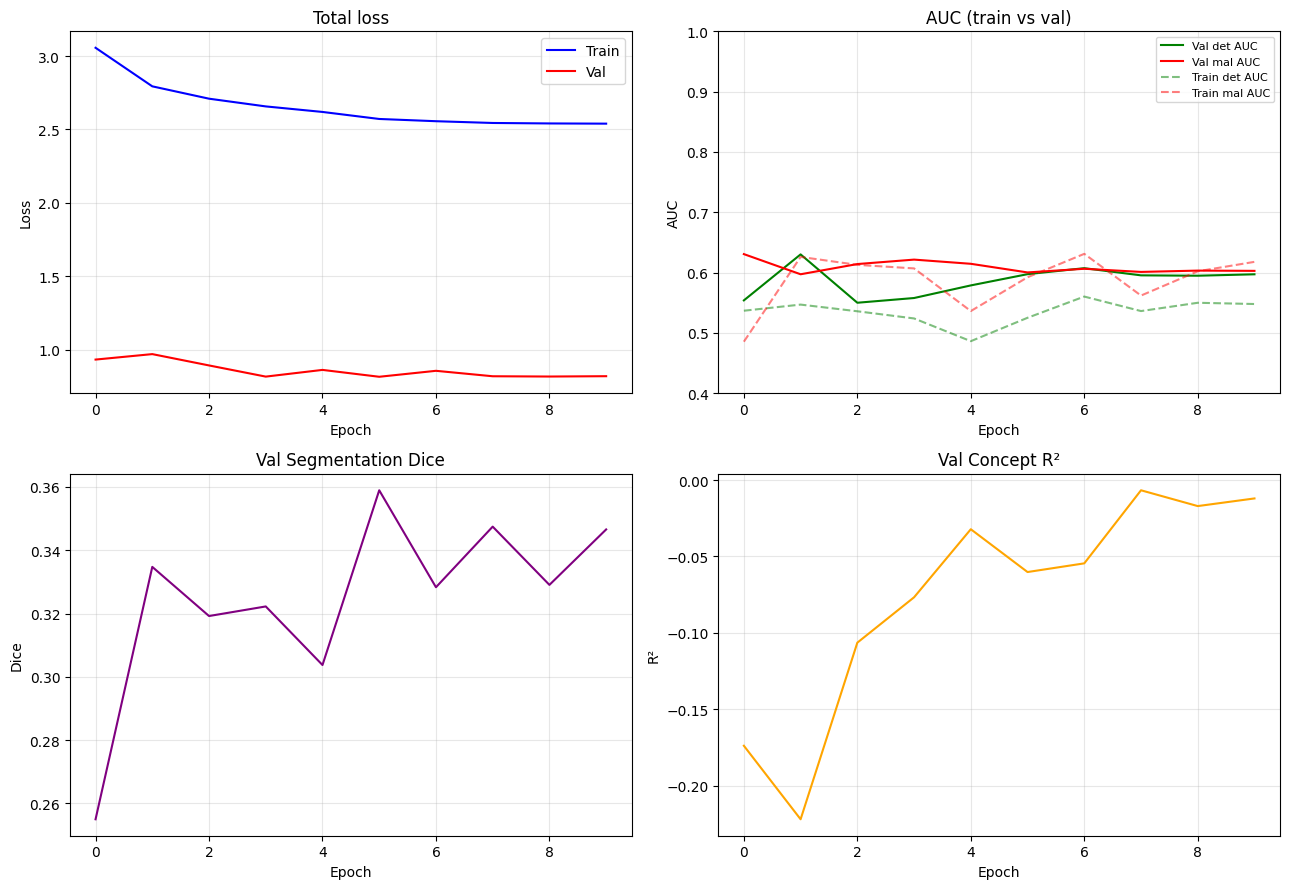

Training history kaydedildi ✅


In [22]:
if history:
    epochs_arr = [h['epoch'] for h in history]
    train_total = [h['train_losses']['total'] for h in history]      # 'train' → 'train_losses'
    val_total = [h['val']['losses']['total'] for h in history]
    val_det_auc = [h['val']['det_auc'] for h in history]
    val_mal_auc = [h['val']['mal_auc'] for h in history]
    val_dice = [h['val']['seg_dice'] for h in history]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    axes[0,0].plot(epochs_arr, train_total, 'b-', label='Train')
    axes[0,0].plot(epochs_arr, val_total, 'r-', label='Val')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].set_title('Total loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    # v4 bonus: train AUC'ları da çiz (gap görsel olarak)
    axes[0,1].plot(epochs_arr, val_det_auc, 'g-', label='Val det AUC')
    axes[0,1].plot(epochs_arr, val_mal_auc, 'r-', label='Val mal AUC')
    train_det = [h['train_metrics']['det_auc'] if h.get('train_metrics') else None for h in history]
    train_mal = [h['train_metrics']['mal_auc'] if h.get('train_metrics') else None for h in history]
    if all(v is not None for v in train_det):
        axes[0,1].plot(epochs_arr, train_det, 'g--', alpha=0.5, label='Train det AUC')
        axes[0,1].plot(epochs_arr, train_mal, 'r--', alpha=0.5, label='Train mal AUC')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('AUC')
    axes[0,1].set_title('AUC (train vs val)'); axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)
    axes[0,1].set_ylim(0.4, 1.0)

    axes[1,0].plot(epochs_arr, val_dice, 'purple')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Dice')
    axes[1,0].set_title('Val Segmentation Dice'); axes[1,0].grid(alpha=0.3)

    val_concept = [h['val']['concept_r2'] for h in history]
    axes[1,1].plot(epochs_arr, val_concept, 'orange')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('R²')
    axes[1,1].set_title('Val Concept R²'); axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=100)
    plt.show()

print('Training history kaydedildi ✅')